<a href="https://colab.research.google.com/github/Cassio295/Cassio295/blob/master/Diagnostico_de_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A proposta desse projeto é montar um modelo que possa ser capaz classificar pacientes com diabetes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

diabetes_df = pd.read_csv('dataset_diabetes.csv', sep= ',')


##Análise exploratória dos dados

In [ ]:
diabetes_df.head()

,Gravidez,Glicose,PS,EP,Insulina,IMC,PedigreeDiabetes,Idade,Diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes_df.shape

(768, 9)

In [ ]:
diabetes_df.describe()

,Gravidez,Glicose,PS,EP,Insulina,IMC,PedigreeDiabetes,Idade,Diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gravidez          768 non-null    int64  
 1   Glicose           768 non-null    int64  
 2   PS                768 non-null    int64  
 3   EP                768 non-null    int64  
 4   Insulina          768 non-null    int64  
 5   IMC               768 non-null    float64
 6   PedigreeDiabetes  768 non-null    float64
 7   Idade             768 non-null    int64  
 8   Diabetes          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Usando a biblioteca SWEERVIZ para fazer EDA
!pip install sweetviz

import sweetviz as sv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 41.6 MB/s eta 0:00:00


In [ ]:
analise = sv.analyze(diabetes_df)
analise.show_html('diabetes.html')

                                             |          | [  0%]   00:00 -> (? left)

Report diabetes.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Todos os dados estão formatados como números inteiros ou flutuantes para a aplicação dos algoritmos está ótimo

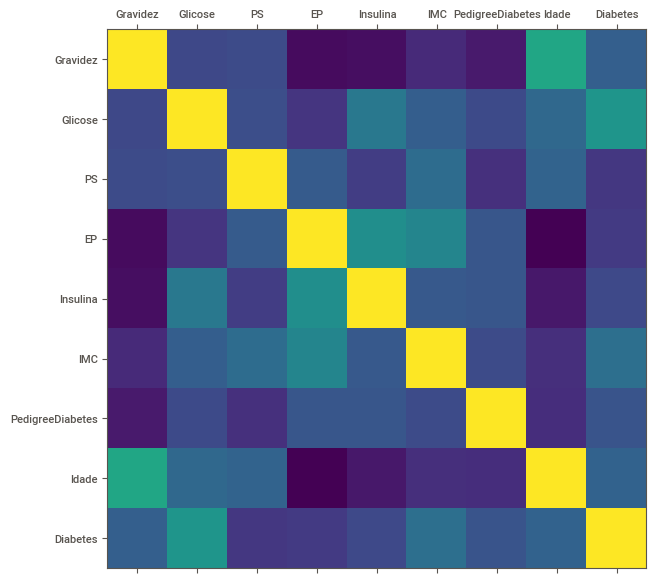

In [ ]:
# Criando a função de matrix de correlação
def plot_corr(df, size = 7):
  corr = df.corr()
  fig, ax = plt.subplots(figsize = (size, size))
  ax.matshow(corr)
  plt.xticks(range(len(corr.columns)), corr.columns)
  plt.yticks(range(len(corr.columns)), corr.columns)
plot_corr(diabetes_df)

In [ ]:
# Outra maneira de avaliar a corelaçao entre as variáveis
import seaborn as sns
sns.set(color_codes=True)
cor = diabetes_df.corr()
cor

,Gravidez,Glicose,PS,EP,Insulina,IMC,PedigreeDiabetes,Idade,Diabetes
Gravidez,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glicose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
PS,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
EP,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulina,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
IMC,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
PedigreeDiabetes,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Idade,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [ ]:
# Matrix de correlação
sns.heatmap(cor, annot=True)

NameError: name 'plt' is not defined

In [ ]:
num_true = len(diabetes_df.loc[diabetes_df['Diabetes'] ==True])
num_false = len(diabetes_df.loc[diabetes_df['Diabetes'] == False])
print(f'Número de Casos Verdadeiros {num_true} ({num_true / (num_true + num_false) *100 :.2f}%)')
print(f'Número de Casos False {num_false} {num_false / (num_true + num_false) * 100 :.2f}%')

Número de Casos Verdadeiros 268 (34.90%)
Número de Casos False 500 65.10


##Dividindo o Banco de Dados
Para melhorar a análise, vamos dividir nosso banco de dados em 2:
1 banco de dados de treino
2 banco de dados de teste

In [ ]:
from sklearn.model_selection import train_test_split
#Dividindo o meu x
X = diabetes_df.drop(['Diabetes'], axis=1)
y = diabetes_df['Diabetes']

# display(X)
# print(y)

In [ ]:
X = X.values
y = y.values

In [ ]:
#Deixando 30% da base para meus testes
split_test_size = 0.30
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y,test_size= split_test_size, random_state=42)

In [ ]:
print("{0:0.2f}% nos dados de treino".format((len(X_treino)/len(diabetes_df.index)) * 100))
print("{0:0.2f}% nos dados de teste".format((len(X_teste)/len(diabetes_df.index)) * 100))

69.92% nos dados de treino
30.08% nos dados de teste


##**Valores Missing ocultos**

In [ ]:
# Vamos verificar os valores faltantes ou zerados
print(f'Linhas do DataFrame {len(diabetes_df)}')
print(f'Linhas missing Glicose: {len(diabetes_df.loc[diabetes_df["Glicose"] == 0])}')
print(f'Linhas missing PS: {len(diabetes_df.loc[diabetes_df["PS"] == 0])}')
print(f'Linhas missing EP: {len(diabetes_df.loc[diabetes_df["EP"] == 0])}')
print(f'Linhas missing Insulina: {len(diabetes_df.loc[diabetes_df["Insulina"] == 0])}')
print(f'Linhas missing IMC: { len(diabetes_df.loc[diabetes_df["IMC"] == 0 ])}')
print(f'Linhas missing Idade: { len(diabetes_df.loc[diabetes_df["Idade"]] == 0)}')


Linhas do DataFrame 768
Linhas missing Glicose: 5
Linhas missing PS: 35
Linhas missing EP: 227
Linhas missing Insulina: 374
Linhas missing IMC: 11
Linhas missing Idade: 768


##Tratando os dados Missing

Inputação de dados: subistituindo os valores zerados pela média dos dados.

In [ ]:
from sklearn.impute import SimpleImputer
preenche_0 = SimpleImputer(missing_values=0, strategy = "mean")
X_treino = preenche_0.fit_transform(X_treino)
X_teste = preenche_0.fit_transform(X_teste)

In [ ]:
X_treino

array([[  1.        ,  95.        ,  60.        , ...,  23.9       ,
          0.26      ,  22.        ],
       [  5.        , 105.        ,  72.        , ...,  36.9       ,
          0.159     ,  28.        ],
       [  4.34056399, 135.        ,  68.        , ...,  42.3       ,
          0.365     ,  24.        ],
       ...,
       [ 10.        , 101.        ,  86.        , ...,  45.6       ,
          1.136     ,  38.        ],
       [  4.34056399, 141.        ,  72.24131274, ...,  42.4       ,
          0.205     ,  29.        ],
       [  4.34056399, 125.        ,  96.        , ...,  22.5       ,
          0.262     ,  21.        ]])

### Resultados aplicando os algoritimos de aprendizado de máquina



In [ ]:
# Modelo de Reressão Logística
from sklearn.linear_model import LogisticRegression

# Imprementando o modelo
modelo_lr = LogisticRegression(C = 0.7, random_state = 42, max_iter= 1000)
modelo_lr.fit(X_treino, y_treino.ravel())
y_forecast_lr = modelo_lr.predict(X_teste)


[0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1
 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 1 0
 0 0 0 1 0 0 0 0 0]


In [ ]:
# Aplicando as metricas de avaliação do modelo
from sklearn.metrics import accuracy_score, classification_report
print(f'Acurácio do Modelo de Regressão Logística: {accuracy_score(y_teste, y_forecast_lr) *100 :.2f}')
print()
print(classification_report(y_teste, y_forecast_lr, labels = [1,2], zero_division=True))

Acurácio do Modelo de Regressão Logística: 73.59

              precision    recall  f1-score   support

           1       0.63      0.59      0.61        80
           2       1.00      1.00      1.00         0

   micro avg       0.63      0.59      0.61        80
   macro avg       0.81      0.79      0.80        80
weighted avg       0.63      0.59      0.61        80



In [ ]:
# KNN (K nearest neighbor)
from sklearn.neighbors import KNeighborsClassifier
modelo_KNN = KNeighborsClassifier(n_neighbors=5)

modelo_KNN.fit(X_treino, y_treino)
y_forecast_KNN = modelo_KNN.predict(X_teste)

In [ ]:
print("Exatidão (Accuracy): {0:.4f}".format(accuracy_score(y_teste, y_forecast_KNN)))
print()
print("Classification Report")
print(classification_report(y_teste, y_forecast_KNN, labels = [1, 0]))

Exatidão (Accuracy): 0.6797

Classification Report
              precision    recall  f1-score   support

           1       0.53      0.59      0.56        80
           0       0.77      0.73      0.75       151

    accuracy                           0.68       231
   macro avg       0.65      0.66      0.65       231
weighted avg       0.69      0.68      0.68       231



In [ ]:
# árvore de desição
from sklearn.tree import DecisionTreeClassifier
modelo_tree = DecisionTreeClassifier(random_state =1)

modelo_tree.fit(X_treino, y_treino)

y_forecast_tree = modelo_tree.predict(X_teste)

In [ ]:
print(f'Exatidão (Acurracy): {accuracy_score(y_teste, y_forecast_tree) *100}')
print()
print('Classification Report')
print(classification_report(y_teste, y_forecast_tree))

Exatidão (Acurracy): 73.16017316017316

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       151
           1       0.61      0.64      0.62        80

    accuracy                           0.73       231
   macro avg       0.70      0.71      0.71       231
weighted avg       0.73      0.73      0.73       231



In [ ]:
# MLP
from sklearn.neural_network import MLPClassifier
modelo_mlp = MLPClassifier(solver='lbfgs', alpha = 1e-5, hidden_layer_sizes=(5,10), random_state=1)

modelo_mlp.fit(X_teste , y_teste)

y_forecast_mlp = modelo_mlp.predict(X_teste)


In [ ]:
print(f'Acurácia do Modelo de MLP: {accuracy_score(y_teste, y_forecast_mlp) *100}')
print()
print('Classification Report')
print(classification_report(y_teste, y_forecast_mlp, labels= [1,0]))

Acurácia do Modelo de MLP: 66.66666666666666

Classification Report
              precision    recall  f1-score   support

           1       1.00      0.04      0.07        80
           0       0.66      1.00      0.80       151

    accuracy                           0.67       231
   macro avg       0.83      0.52      0.43       231
weighted avg       0.78      0.67      0.55       231



## **Comparando a exatidão (acurácia) de todos os modelos**


In [ ]:
print(f'Acurácia do Modelo MLP: {accuracy_score(y_teste, y_forecast_mlp)*100 :.2f}')
print(f'Acurácia do Modelo KNN: {accuracy_score(y_teste, y_forecast_KNN)*100 :.2f}')
print(f'Acurácia do Modelo Decision Tree: {accuracy_score(y_teste, y_forecast_tree)*100 :.2f}')
print(f'Acurácia do Modelo de Regressão Logística: {accuracy_score(y_teste, y_forecast_lr)*100 :.2f}')

Acurácia do Modelo MLP: 66.67
Acurácia do Modelo KNN: 67.97
Acurácia do Modelo Decision Tree: 73.16
Acurácia do Modelo de Regressão Logística: 73.59


## **Vamos fazer previsões com o modelo treinado!**

In [ ]:
import pickle

In [ ]:
filename = 'modelo_lr_treinado.sav'
pickle.dump(y_forecast_lr, open(filename, 'wb'))